# OV2295 Zenodo Data

In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

import scgenome

sample_ids = [
    'SA1090',
    'SA921',
    'SA922',
]



Download zenodo data using wget:

```
mkdir zenodo_data/
wget https://zenodo.org/record/5725635/files/ov2295_cell_cn.csv.gz?download=1 -O zenodo_data/ov2295_cell_cn.csv.gz
wget https://zenodo.org/record/5725635/files/ov2295_cell_metrics.csv.gz?download=1 -O zenodo_data/ov2295_cell_metrics.csv.gz
```



# Load CN data


In [2]:

cn_data = pd.read_csv(
    'zenodo_data/ov2295_cell_cn.csv.gz',
    dtype={
        'cell_id': 'category',
        'sample_id': 'category',
        'library_id': 'category',
        'chr': 'category',
    })

metrics_data = pd.read_csv(
    'zenodo_data/ov2295_cell_metrics.csv.gz',
    dtype={
        'cell_id': 'category',
        'sample_id': 'category',
        'library_id': 'category',
    })

scgenome.utils.union_categories([cn_data, metrics_data])

hmmcopy = scgenome.pp.convert_dlp_hmmcopy(metrics_data, cn_data)



# Basic quality filtering


In [3]:
hmmcopy.obs.columns

Index(['unpaired_mapped_reads', 'paired_mapped_reads',
       'unpaired_duplicate_reads', 'paired_duplicate_reads', 'unmapped_reads',
       'percent_duplicate_reads', 'estimated_library_size', 'total_reads',
       'total_mapped_reads', 'total_duplicate_reads', 'total_properly_paired',
       'coverage_breadth', 'coverage_depth', 'median_insert_size',
       'mean_insert_size', 'standard_deviation_insert_size', 'index_sequence',
       'column', 'img_col', 'index_i5', 'sample_type', 'primer_i7',
       'experimental_condition', 'index_i7', 'cell_call', 'sample_id',
       'primer_i5', 'row', 'library_id', 'index', 'multiplier',
       'MSRSI_non_integerness', 'MBRSI_dispersion_non_integerness',
       'MBRSM_dispersion', 'autocorrelation_hmmcopy', 'cv_hmmcopy',
       'empty_bins_hmmcopy', 'mad_hmmcopy', 'mean_hmmcopy_reads_per_bin',
       'median_hmmcopy_reads_per_bin', 'std_hmmcopy_reads_per_bin',
       'total_mapped_reads_hmmcopy', 'total_halfiness', 'scaled_halfiness',
       'm

In [4]:

hmmcopy = hmmcopy[
    (hmmcopy.obs['total_reads'] > 500000) &
    (hmmcopy.obs['quality'] > 0.75)]


# Plot a cell

<Axes: xlabel='chromosome'>

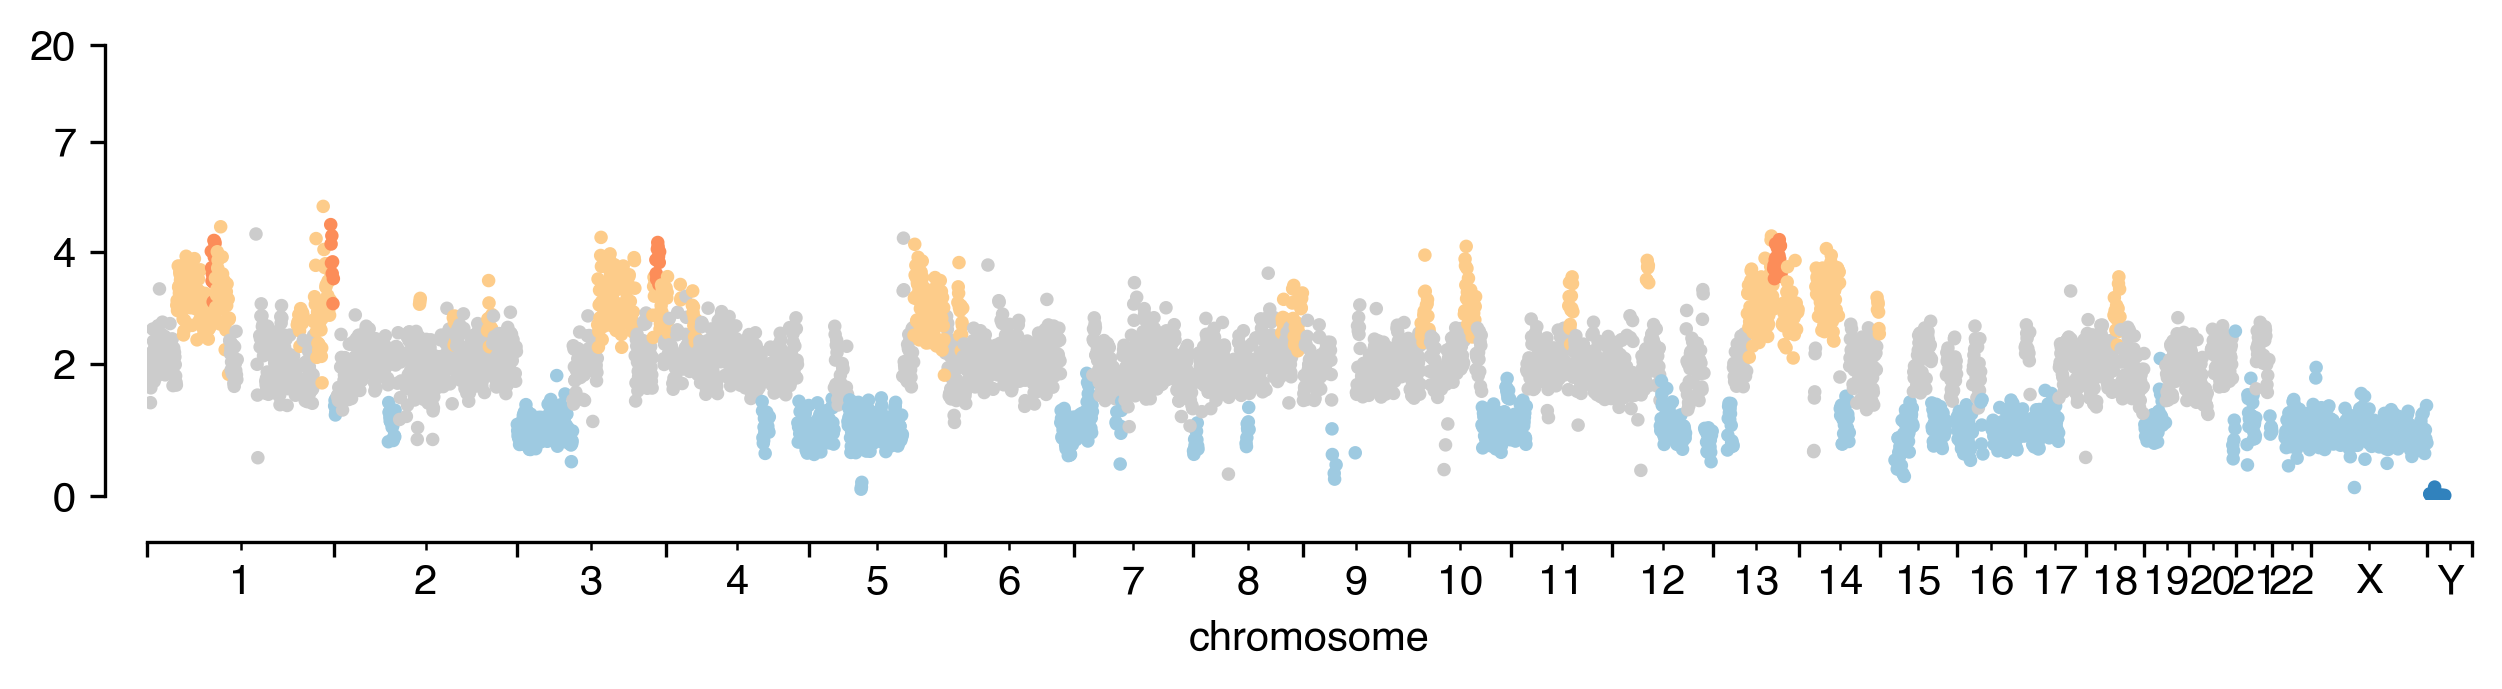

In [5]:

cell_id = hmmcopy.obs.index[0]

plt.figure(figsize=(10, 2))
scgenome.pl.plot_tcn_profile(
    hmmcopy, cell_id,
    value_layer_name='copy',
    state_layer_name='state',
    squashy=True)



# Calculate clones using kmeans


In [6]:

hmmcopy = scgenome.tl.cluster_cells(hmmcopy, max_k=30)


/Users/mcphera1/Projects/scgenome/scgenome/tools/cluster.py:141: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['cluster_id'] = '-1'
/Users/mcphera1/miniconda39/lib/python3.9/contextlib.py:126: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  next(self.gen)
/Users/mcphera1/Projects/scgenome/scgenome/tools/cluster.py:142: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  adata.obs.loc[cell_ids, 'cluster_id'] = pd.Series(opt_label, index=adata.obs.loc[cell_ids].index).astype('str').astype('category')


<Axes: xlabel='cluster_id', ylabel='cluster_size'>

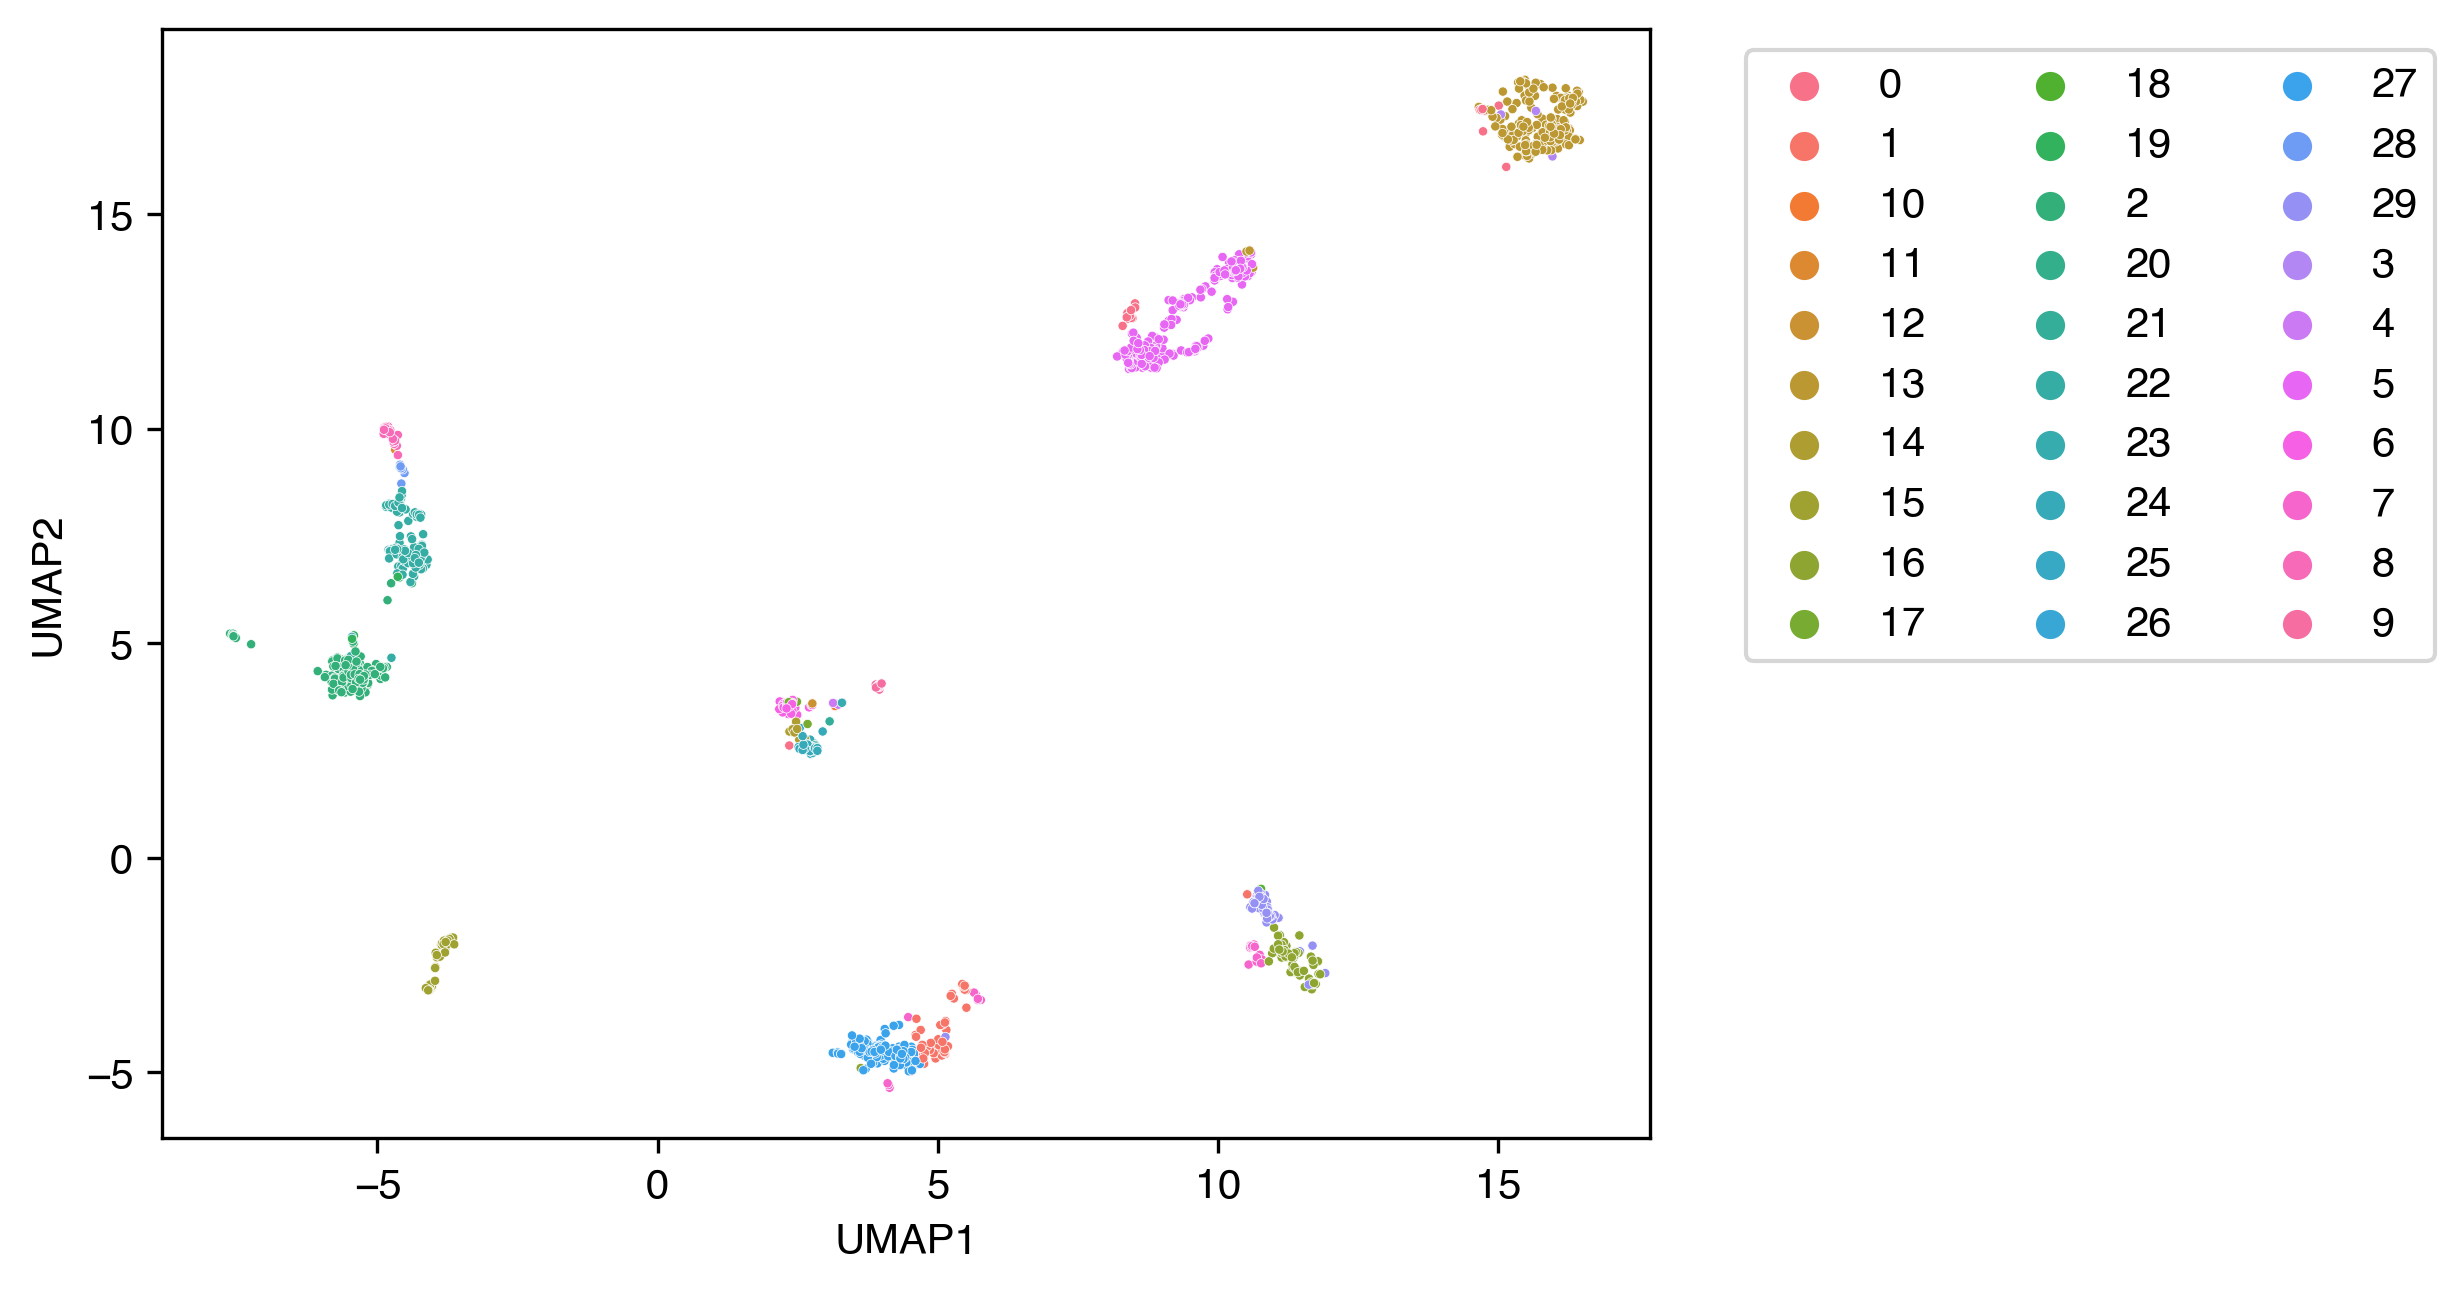

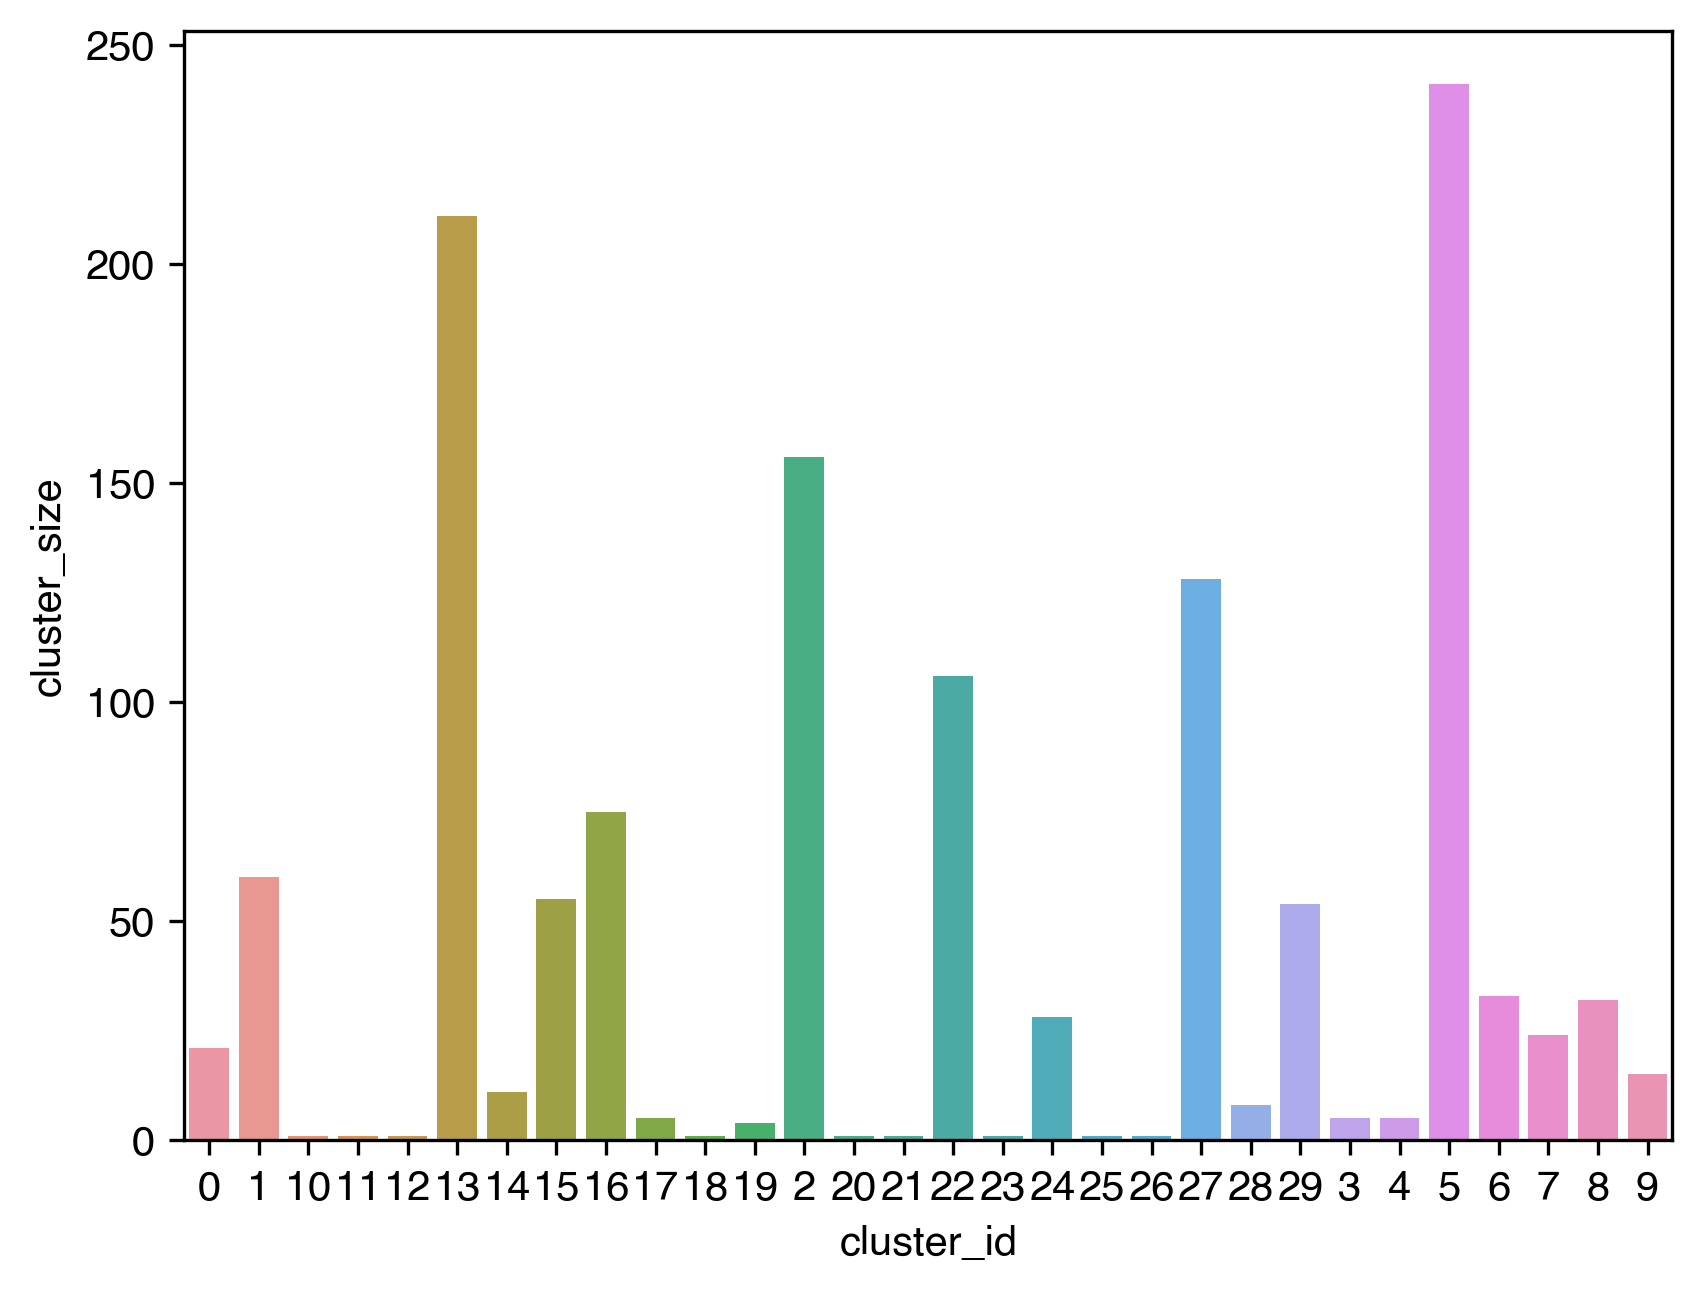

In [7]:

scgenome.tl.compute_umap(hmmcopy)

plt.figure()
sns.scatterplot(data=hmmcopy.obs, x='UMAP1', y='UMAP2', hue='cluster_id', s=5)
plt.legend(ncols=3, bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.figure()
sns.barplot(data=hmmcopy.obs, x='cluster_id', y='cluster_size')



# Plot heatmap

Order by cluster, then by a secondary ordering from hierarchical clustering.


/Users/mcphera1/Projects/scgenome/scgenome/tools/sorting.py:66: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Y = sch.linkage(D, method='complete')
/Users/mcphera1/Projects/scgenome/scgenome/tools/sorting.py:74: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  adata.obs.loc[cell_ids, 'cell_order'] = pd.Series(ordering, index=adata.obs.loc[cell_ids].index)


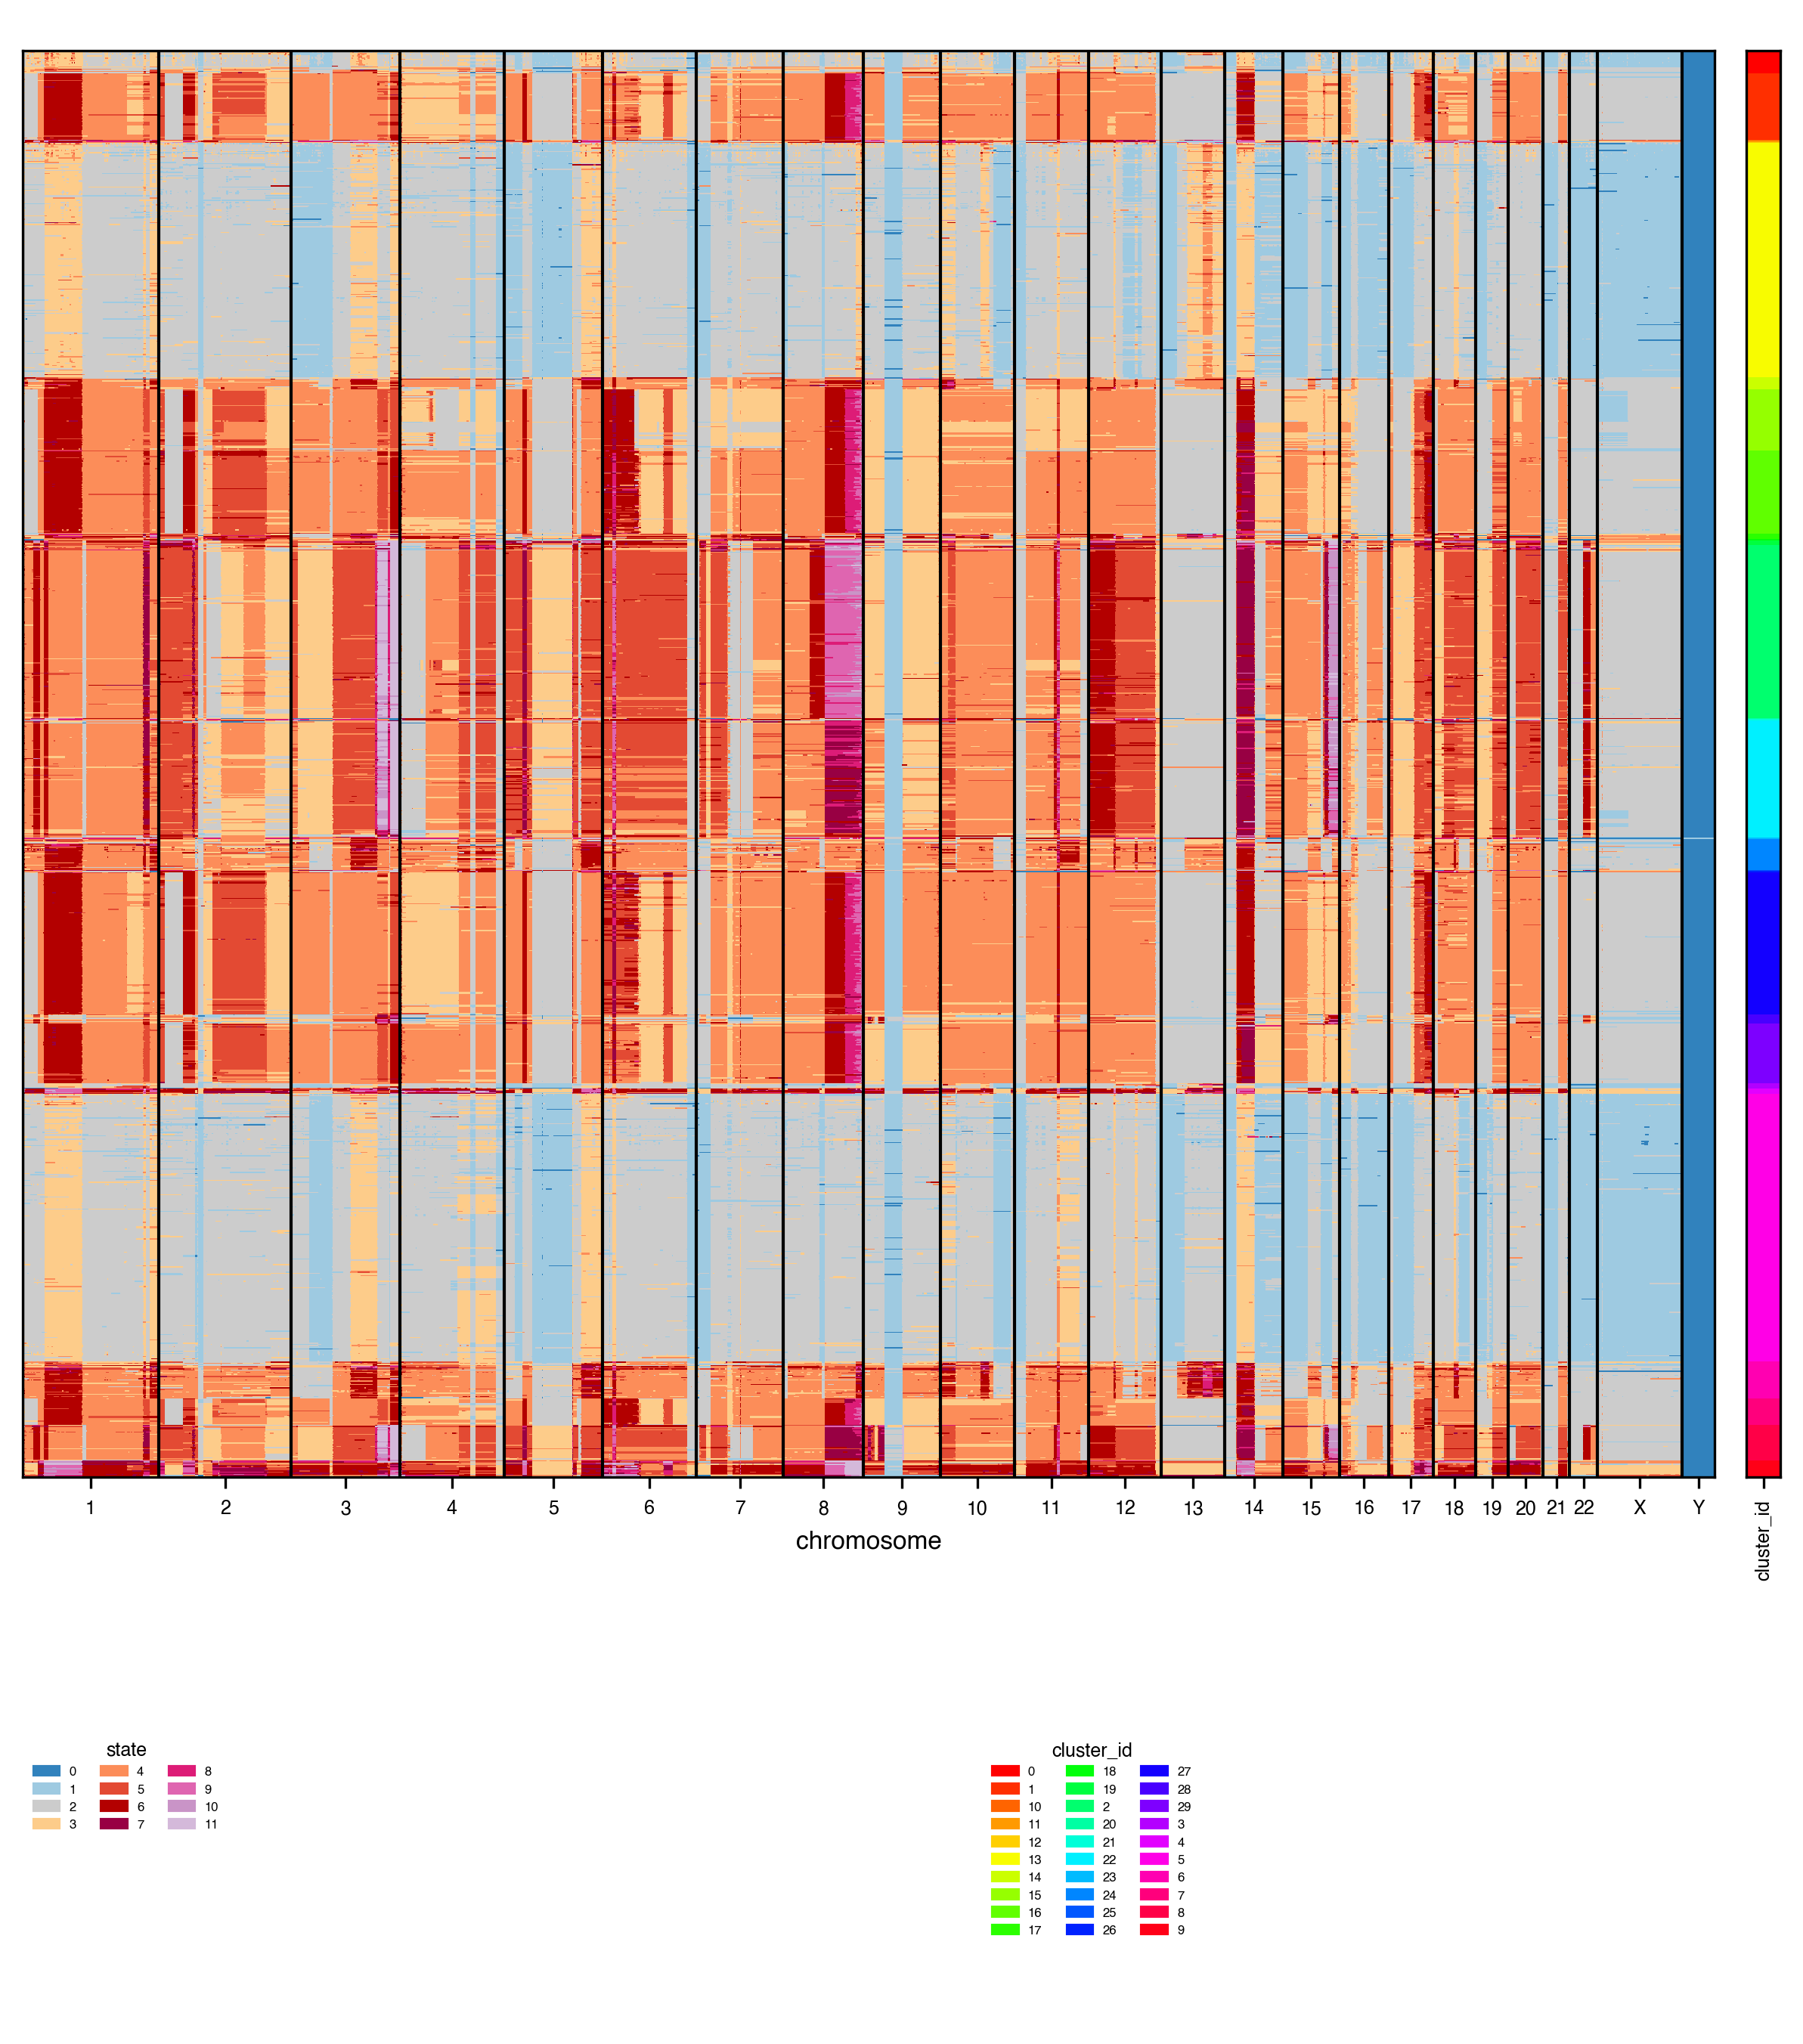

In [8]:

hmmcopy = scgenome.tl.sort_cells(hmmcopy, layer_name='copy')

fig = plt.figure(figsize=(10, 10))
g = scgenome.pl.plot_cell_cn_matrix_fig(
    hmmcopy,
    layer_name='state',
    obs_order_fields=['cluster_id', 'cell_order'],
    annotation_fields=['cluster_id'],
    fig=fig,
)



# Plot PCA components


/Users/mcphera1/Projects/scgenome/scgenome/tools/pca.py:78: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = ad.AnnData(


<Axes: xlabel='chromosome'>

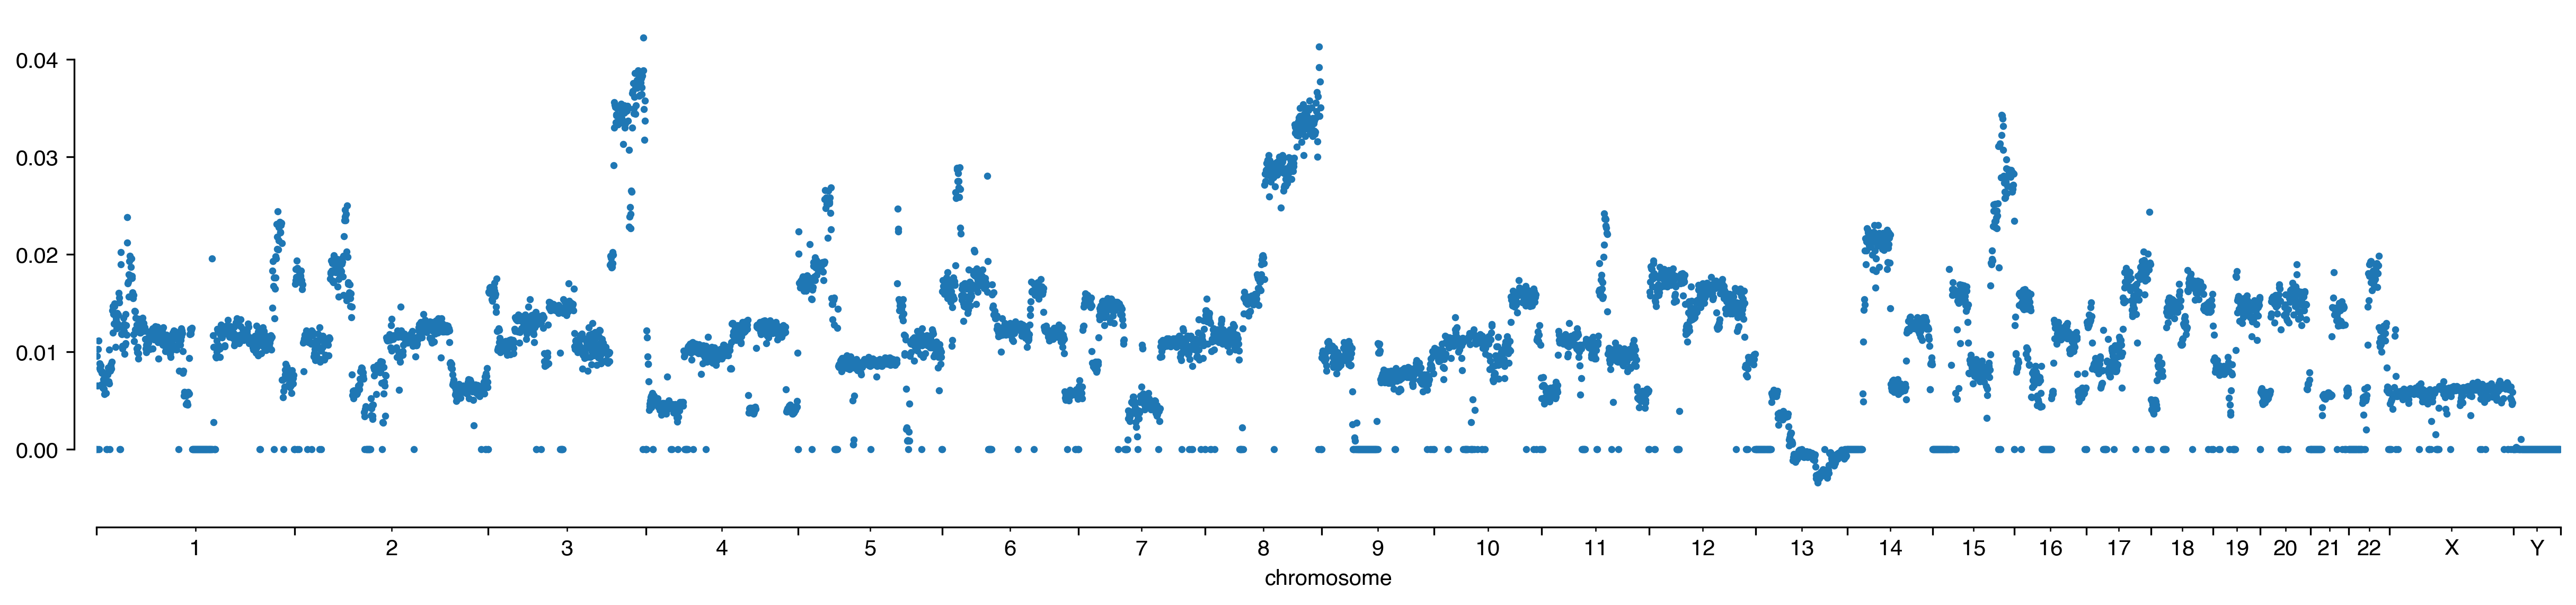

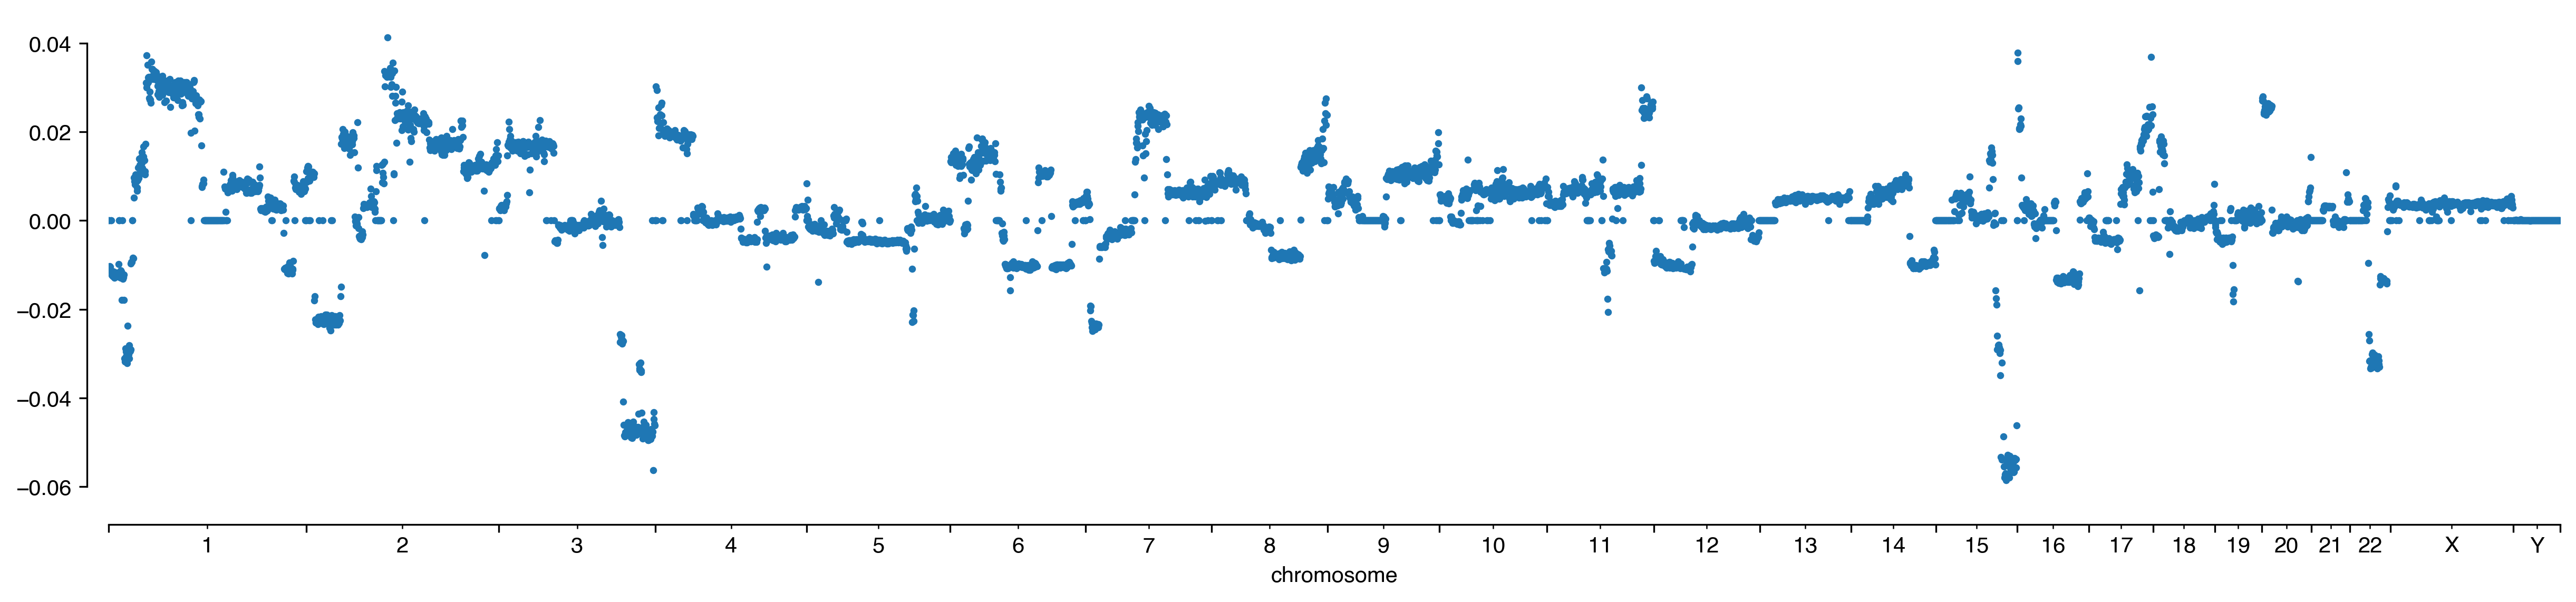

In [9]:

pcadata = scgenome.tl.pca_loadings(hmmcopy, layer='copy')

fig = plt.figure(figsize=(20, 4))
scgenome.pl.plot_tcn_profile(
    pcadata, 'PC1',
    value_layer_name=None,
    rawy=True)

fig = plt.figure(figsize=(20, 4))
scgenome.pl.plot_tcn_profile(
    pcadata, 'PC2',
    value_layer_name=None,
    rawy=True)
